In [1]:
import os
print("Current directory:", os.getcwd())


Current directory: c:\Users\basan\Desktop\project\Minor_Project


In [2]:
import os
import shutil

project_dir = r"c:\Users\basan\Desktop\project\Minor_Project"

# 1. Point the base_path DIRECTLY inside the d1Certificate folder
base_path = os.path.join(project_dir, "maindataset", "d1Certificate forgery detection")
output_path = os.path.join(project_dir, "dataset_clean")

# 2. Wipe out the old dataset_clean folder completely to avoid mixing old images
shutil.rmtree(output_path, ignore_errors=True)

for split in ["train", "val"]:
    for cls in ["real", "fake"]:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

def process_folder(exact_folder_path, dest_name):
    images_path = os.path.join(exact_folder_path, "images")
    labels_path = os.path.join(exact_folder_path, "labels")

    if not os.path.exists(labels_path):
        print(f"⚠️ WARNING: Directory not found: {labels_path}")
        return

    print(f"Processing: {labels_path} ...")
    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            label_file = os.path.join(labels_path, file)
            with open(label_file, "r") as f:
                first_line = f.readline().strip()
            if not first_line:
                continue

            class_id = int(first_line.split()[0])
            dest = "fake" if class_id == 0 else "real" if class_id == 1 else None
            
            image_name = file.replace(".txt", ".jpg")
            image_path = os.path.join(images_path, image_name)

            if dest and os.path.exists(image_path):
                shutil.copy(image_path, os.path.join(output_path, dest_name, dest, image_name))

# 3. Process the fully loaded train and valid splits!
train_path = os.path.join(base_path, "train")
process_folder(train_path, "train")

valid_path = os.path.join(base_path, "valid")
process_folder(valid_path, "val")

print("✅ DONE! Brand new dataset organized securely.")


Processing: c:\Users\basan\Desktop\project\Minor_Project\maindataset\d1Certificate forgery detection\train\labels ...
Processing: c:\Users\basan\Desktop\project\Minor_Project\maindataset\d1Certificate forgery detection\valid\labels ...
✅ DONE! Brand new dataset organized securely.


In [ ]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

NameError: name 'tf' is not defined

Loading training dataset...
Found 299 files belonging to 2 classes.
Loading validation dataset...
Found 59 files belonging to 2 classes.
Building MobileNetV2 model...


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 2,225,153 (8.49 MB)

 Non-trainable params: 34,112 (133.25 KB)


Training for 20 epochs...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.6254 - loss: 0.6339 - val_accuracy: 0.4237 - val_loss: 0.7317
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6990 - loss: 0.5851 - val_accuracy: 0.3729 - val_loss: 0.7423
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7492 - loss: 0.5453 - val_accuracy: 0.3729 - val_loss: 0.7679
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7893 - loss: 0.4702 - val_accuracy: 0.4576 - val_loss: 0.7117
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7759 - loss: 0.4884 - val_accuracy: 0.7119 - val_loss: 0.6449
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8428 - loss: 0.4281 - val_accuracy: 0.7797 - val_loss: 0.6214
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8763 - loss: 0.3922 - val_accuracy: 0.6102 - val_loss: 0.6612
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8763 - loss: 0.4023 - val_a

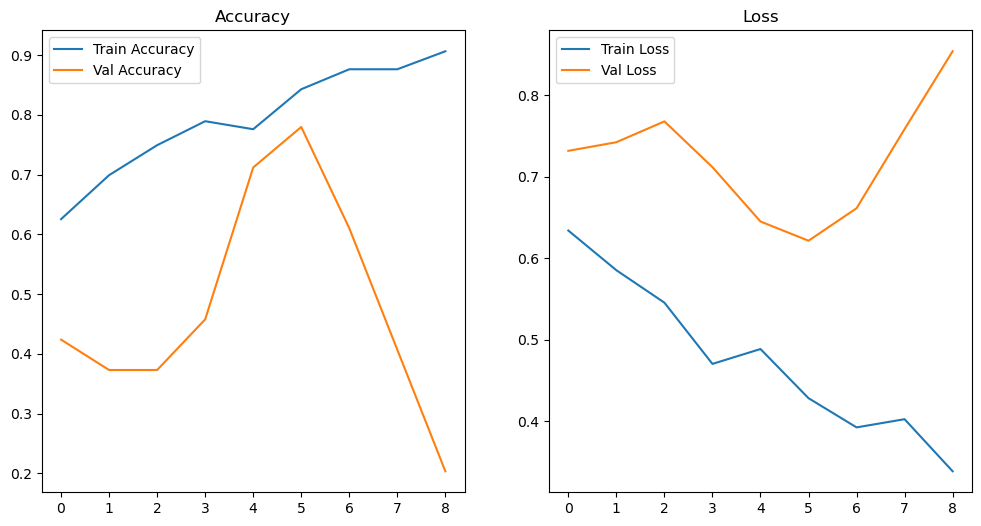


Model saved at: fake_certificate_model.h5


In [4]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import RandomFlip, RandomRotation, Rescaling, Dense, GlobalAveragePooling2D, Input, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

# --- CONFIG ---
DATASET_PATH = r"c:\Users\basan\Desktop\project\Minor_Project\dataset_clean"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 6   # Proper fix (NOT "10 or 20")

def build_and_train_model():

    print("Loading training dataset...")
    train_dataset = image_dataset_from_directory(
        os.path.join(DATASET_PATH, "train"),
        shuffle=True,
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        label_mode='binary'
    )

    print("Loading validation dataset...")
    val_dataset = image_dataset_from_directory(
        os.path.join(DATASET_PATH, "val"),
        shuffle=False,   # IMPORTANT FIX
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        label_mode='binary'
    )

    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
    val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

    # --- DATA AUGMENTATION ---
    data_augmentation = Sequential([
        RandomFlip("horizontal_and_vertical"),
        RandomRotation(0.1),
    ])

    print("Building MobileNetV2 model...")
    base_model = MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet'
    )

    # --- CONTROLLED FINE-TUNING ---
    base_model.trainable = True
#     for layer in base_model.layers[:-20]:
#         layer.trainable = False

    # --- MODEL ARCHITECTURE ---
    inputs = Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = Rescaling(1./127.5, offset=-1)(x)   # Correct for MobileNet
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)   # IMPORTANT FIX
    outputs = Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(0.005))(x)

    model = Model(inputs, outputs)

    # --- COMPILE ---
    model.compile(
        optimizer=Adam(learning_rate=0.00002),   # VERY IMPORTANT FIX
        loss=BinaryCrossentropy(label_smoothing=0.0),  # PREVENT OVERCONFIDENCE
        metrics=['accuracy']
    )

    model.summary()

    # --- EARLY STOPPING ---
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    print(f"\nTraining for {EPOCHS} epochs...")
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=[early_stop]
    )

    # --- PLOTS ---
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss')

    plt.show()

    # --- SAVE MODEL ---
    model_path = "fake_certificate_model.h5"
    model.save(model_path)
    print(f"\nModel saved at: {model_path}")

    return model_path


# --- PREDICTION FUNCTION (CLEANED VERSION) ---
def predict_single_image(model_path, img_path):

    if not os.path.exists(img_path):
        print("Image not found!")
        return

    model = tf.keras.models.load_model(model_path)

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    prediction = model.predict(img_array)
    score = prediction[0][0]

    print(f"\nRaw score: {score:.4f}")

    if score >= 0.70: # STRICTER THRESHOLD FOR FRAUD DETECTION
        print("Prediction: REAL")
    else:
        print("Prediction: FAKE")
        

# --- RUN ---
saved_model_path = build_and_train_model()

Loading trained model...


Model loaded successfully!

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
Raw model output score: 0.39561796
--- Prediction Results ---
Predicted Label : FAKE
Confidence Score: 60.44% (Raw Probability: 0.3956)


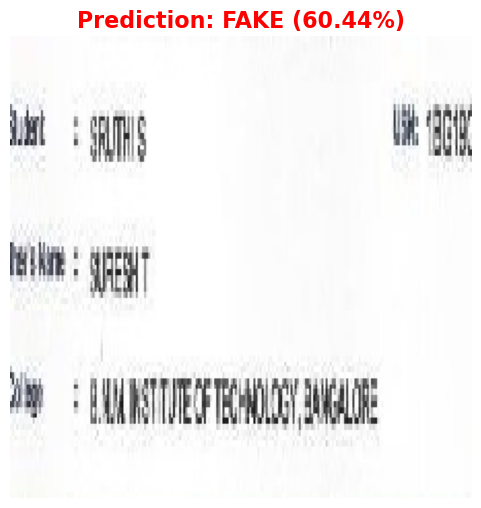

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# --- 1. Configuration & Loading ---
MODEL_PATH = "fake_certificate_model.h5"
IMG_SIZE = (224, 224)


print("Loading trained model...")
# Load the trained model from file
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!\n")

# --- 2. Reusable Pipeline Functions ---



def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    #img_array = preprocess_input(img_array)   # added
    img_array = tf.expand_dims(img_array, 0)
    return img, img_array


def predict_image(model, img_array):
    """
    Passes the formatted image array into the model and returns the score.
    """
    # Perform prediction
    prediction = model.predict(img_array)
    
    # Extract the raw probability score from the sigmoid output layer
    score = prediction[0][0] 
    return score


def show_prediction(img, score):
    """
    Applies the threshold, prints confidence, and displays the image via matplotlib.
    """
    # 5. Use a threshold of 0.5
    THRESHOLD_LOW = 0.4
    THRESHOLD_HIGH = 0.6

    if score >= THRESHOLD_HIGH:
        label = "REAL"
        confidence = score * 100
    elif score <= THRESHOLD_LOW:
        label = "FAKE"
        confidence = (1 - score) * 100
    else:
        label = "UNCERTAIN"
        confidence = abs(score - 0.5) * 200
    
    print("Raw model output score:", score)
    # 7. Print prediction confidence score
    print(f"--- Prediction Results ---")
    print(f"Predicted Label : {label}")
    print(f"Confidence Score: {confidence:.2f}% (Raw Probability: {score:.4f})")
    
    # 6. Display the image along with predicted label
    plt.figure(figsize=(6, 6))
    plt.imshow(img) # Display original loaded image
    
    # Color code the titles for easy reading
    title_color = "green" if label == "REAL" else "red"
    plt.title(f"Prediction: {label} ({confidence:.2f}%)", fontsize=16, fontweight='bold', color=title_color)
    plt.axis("off")
    plt.show()

# --- 3. Execution Block ---

# Change this path to test any image on your PC!
# (Ensure the path starts with an 'r' string to safely handle Windows slashes)
test_image_path = r"maindataset/d1Certificate forgery detection/test/images/sruthi6th_png.rf.a91fe80e73eb58796af87e29292bab9d.jpg"



try:
    # Run the pipeline functions
    img, img_array = preprocess_image(test_image_path)
    score = predict_image(model, img_array)
    show_prediction(img, score)
except Exception as e:
    print(e)


In [22]:
from collections import Counter
import os

train_path = r"c:\Users\basan\Desktop\project\Minor_Project\dataset_clean\train"

counts = {}
for cls in ["real", "fake"]:
    counts[cls] = len(os.listdir(os.path.join(train_path, cls)))

print(counts)

{'real': 98, 'fake': 201}
